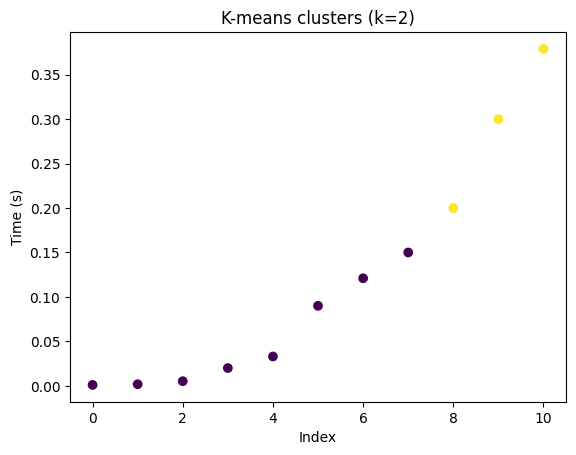

In [ ]:
from scipy.cluster.vq import kmeans, whiten
import matplotlib.pyplot as plt
import numpy as np


def ms(seconds: float) -> float:
    return seconds / 1000


data = sorted([ms(1), ms(1.8), ms(5.2), ms(121), ms(150), ms(379), ms(200), ms(300), ms(33), ms(90), ms(20)])

whitened = whiten(data)
centroids, _ = kmeans(whitened, 2)

# Assign each point to the nearest centroid.
labels = np.argmin(np.abs(whitened[:, None] - centroids[None, :]), axis=1)

plt.scatter(range(len(data)), data, c=labels, cmap="viridis")
plt.xlabel("Index")
plt.ylabel("Time (s)")
plt.title("K-means clusters (k=2)")
plt.show()

In [ ]:
def split_nodes(latencies: list[float]) -> tuple[list[float], list[float]]:
    sorted_vals = sorted(latencies)
    best_cost = float("inf")
    best_i = 1
    log_vals = np.log(sorted_vals)

    for i in range(1, len(sorted_vals)):
        cost = max(np.std(log_vals[:i]), np.std(log_vals[i:]))
        if cost < best_cost:
            best_cost = cost
            best_i = i

    return sorted_vals[:best_i], sorted_vals[best_i:]

split_nodes([ms(1), ms(1.8), ms(5.2), ms(121), ms(150), ms(379), ms(200), ms(300), ms(33), ms(90), ms(20), ms(400)])
np.log([ms(10), ms(50), ms(100), ms(1000), ms(10_000)])

def split_nodes(latencies: list[float]) -> tuple[list[float], list[float]]:
    sorted_vals = sorted(latencies)
    log_vals = np.log(sorted_vals)
    gaps = np.diff(log_vals)

    # Only consider gaps that are significantly above the median.
    threshold = np.median(gaps) + np.std(gaps)
    candidates = np.where(gaps >= threshold)[0]

    if len(candidates) == 0:
        # No clear split — all nodes are roughly equivalent.
        return sorted_vals, []

    # Among significant gaps, pick the largest.
    best_i = int(candidates[np.argmax(gaps[candidates])]) + 1
    return sorted_vals[:best_i], sorted_vals[best_i:]

split_nodes([ms(1), ms(1.8), ms(5.2), ms(121), ms(150), ms(379), ms(200), ms(300), ms(33), ms(90), ms(20), ms(400)])
split_nodes([ms(10), ms(50), ms(100), ms(1000)])

def split_nodes(latencies: list[float], *, knob: float = 2) -> tuple[list[float], list[float]]:
      sorted_vals = sorted(latencies)
      threshold = sorted_vals[0] * knob
      i = np.searchsorted(sorted_vals, threshold, side="right")
      return sorted_vals[:i], sorted_vals[i:]

split_nodes([ms(1), ms(1.8), ms(5.2), ms(121), ms(150), ms(379), ms(200), ms(300), ms(33), ms(90), ms(20), ms(400)])
split_nodes([ms(10), ms(50), ms(100), ms(1000)])

([0.01], [0.05, 0.1, 1.0])